# TP2 — Reconstrucción 3D con cámara estéreo

**I308 Visión Artificial · UdeSA · Santiago Luis Groba Alonso - Valentino Nallib Fadel - Joaquin Gustavo Di Cola**

Reconstrucción 3D de un objeto rígido (buda) a partir de pares de imágenes RGB capturados con la cámara estéreo ELP-USB3D1080P02-H120. Las celdas markdown describen, en pasado, lo que hace cada etapa — sirven tanto de guía para escribir el código como de borrador para el informe.

## 0. Setup

Importamos las librerias del pipeline (`cv2`, `numpy`, `matplotlib`, `open3d`, `tqdm`) y los modulos locales de catedra: `calib.py` (helpers de calibracion: `board_points`, `np_print`, `draw_checkerboard`) y `aruco.py` (helpers de ChArUco para la pose en escena). Definimos los paths del dataset (`datasets/stereo_propio/`).

In [1]:
import glob
import os
import pickle
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d
from tqdm import tqdm

# Helpers de catedra (copiados localmente desde ejemplos clase/)
import calib   # board_points, detect_board, np_print, draw_checkerboard
import aruco   # create_charuco_board, detect_charuco_markers, ...

# --- Dataset propio ---
DATASET_DIR = Path("datasets/stereo_propio")
CALIB_DIR = DATASET_DIR / "calib"
CAPTURES_DIR = DATASET_DIR / "captures"

# --- Chessboard de calibracion ---
# Hoja A4 con tablero 7x10 cuadrados liso, sin markers. Esquinas internas 6x9.
# Square size: 210 mm (ancho A4) / 7 cuadrados = 30 mm.
CHECKERBOARD = (6, 9)        # (cols, rows) de esquinas internas
SQUARE_SIZE_MM = 30.0

# --- ChArUco board para pose en escena (seccion 4) ---
# Diccionario raro (DICT_ARUCO_MIP_36H12) encontrado por fuerza bruta. Este
# board aparece en las capturas del buda y se usa para anclar el frame del
# mundo en cada toma -- NO se usa para calibrar intrinsecos.
CHARUCO_DICT = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_ARUCO_MIP_36H12)
CHARUCO_MARKER_MM = 64.0   # lado fisico del marker (mm)

print("Setup OK")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Setup OK


## 1. Calibracion estereo

El target de calibracion es un **chessboard liso 7×10 cuadrados** (sin markers ArUco) impreso en A4. Las esquinas internas son **6×9 = 54 puntos por imagen** y cada cuadrado mide 30 mm (210 mm / 7 cuadrados de ancho de A4).

`cv2.findChessboardCorners` (envuelto en `calib.detect_board` con `cornerSubPix`) encuentra las 54 esquinas como una vista coherente por imagen -- sin la ambiguedad planar que tienen los markers individuales. Cada par estereo donde se detecta en AMBAS camaras aporta una vista completa al solver.

**Pipeline**:
1. Detectar el chessboard en cada `left_i.jpg` y `right_i.jpg` (subpix refinement).
2. Acumular las vistas donde se detecta en ambas.
3. Pre-calibrar cada camara con `cv2.calibrateCamera` para obtener intrinsecos iniciales solidos.
4. `cv2.stereoCalibrate` con `CALIB_FIX_INTRINSIC` para estimar solo `R, T` entre camaras.
5. Serializar a `stereo_calibration.pkl`.

> **Nota**: el patron ChArUco chico que aparece en escena (junto al teclado en algunas calib images) NO se usa para calibracion -- es para estimar pose del mundo en cada captura del buda (seccion 4).

In [2]:
# 1.1 Puntos 3D del chessboard en su propio frame
# calib.board_points devuelve un grid (cols * rows, 3) con coordenadas en
# unidades de cuadrado y Z=0. Multiplicamos por SQUARE_SIZE_MM para tener mm.
board_obj_points = (calib.board_points(CHECKERBOARD) * SQUARE_SIZE_MM).astype(np.float32)
print(f"Esquinas internas: {CHECKERBOARD[0]} x {CHECKERBOARD[1]} = {CHECKERBOARD[0]*CHECKERBOARD[1]} puntos / imagen")
print(f"Square size: {SQUARE_SIZE_MM} mm")
print(f"board_obj_points shape: {board_obj_points.shape}")

Esquinas internas: 6 x 9 = 54 puntos / imagen
Square size: 30.0 mm
board_obj_points shape: (1, 54, 3)


In [3]:
# 1.2 Listar pares de imagenes de calibracion (sorted numericamente)
def numeric_sort(file_name):
    return int(os.path.basename(file_name).split("_")[-1].split(".")[0])

left_file_names = sorted(
    glob.glob(str(CALIB_DIR / "*left*.jpg")),
    key=numeric_sort,
)
right_file_names = sorted(
    glob.glob(str(CALIB_DIR / "*right*.jpg")),
    key=numeric_sort,
)
assert len(left_file_names) == len(right_file_names)
print(f"Pares de calibracion en {CALIB_DIR}: {len(left_file_names)}")

Pares de calibracion en datasets\stereo_propio\calib: 163


In [4]:
# 1.3 Loop: detectar chessboard en L y R, paralelizado con ThreadPoolExecutor
# (cv2.findChessboardCorners libera el GIL -> threads dan paralelismo real,
# ~10x con 12 cores). Acumulamos vistas donde se detecta en AMBAS camaras.
from concurrent.futures import ThreadPoolExecutor

def detect_pair(left_fn, right_fn):
    left_image = cv2.imread(left_fn, cv2.IMREAD_GRAYSCALE)
    right_image = cv2.imread(right_fn, cv2.IMREAD_GRAYSCALE)
    sz = (left_image.shape[1], left_image.shape[0])
    ret_L, corners_L = calib.detect_board(CHECKERBOARD, left_image)
    ret_R, corners_R = calib.detect_board(CHECKERBOARD, right_image)
    return sz, ret_L, corners_L, ret_R, corners_R

with ThreadPoolExecutor(max_workers=12) as ex:
    results = list(tqdm(
        ex.map(detect_pair, left_file_names, right_file_names),
        total=len(left_file_names), desc="Detectando chessboard",
    ))

object_points = []
left_images_points = []
right_images_points = []
image_size = None
for sz, ret_L, corners_L, ret_R, corners_R in results:
    if image_size is None:
        image_size = sz
    if not (ret_L and ret_R):
        continue
    object_points.append(board_obj_points)
    left_images_points.append(corners_L)
    right_images_points.append(corners_R)

n_pairs_ok = len(object_points)
print(f"\nPares con chessboard detectado en L y R: {n_pairs_ok} / {len(left_file_names)}")
print(f"image_size = {image_size}")
assert n_pairs_ok >= 15, "Muy pocas vistas, calibracion va a ser mala"

Detectando chessboard: 100%|██████████| 163/163 [00:02<00:00, 56.61it/s]


Pares con chessboard detectado en L y R: 161 / 163
image_size = (1920, 1080)


In [5]:
# 1.4 Calibracion estereo desacoplada: primero cada camara por separado, despues
# stereoCalibrate con CALIB_FIX_INTRINSIC.
# Subsampleamos a MAX_VIEWS evenly-spaced: con >40 vistas el LM se vuelve lento
# y el marginal de informacion es chico (la calibracion satura ~30-40 vistas
# bien distribuidas).
MAX_VIEWS = 40
if n_pairs_ok > MAX_VIEWS:
    idx = np.linspace(0, n_pairs_ok - 1, MAX_VIEWS).astype(int)
    obj_sub  = [object_points[i] for i in idx]
    left_sub = [left_images_points[i] for i in idx]
    right_sub = [right_images_points[i] for i in idx]
    print(f"Sub-sampleando {n_pairs_ok} -> {MAX_VIEWS} vistas para acelerar LM")
else:
    obj_sub, left_sub, right_sub = object_points, left_images_points, right_images_points

n_views = len(obj_sub)

print(f"Pre-calibrando camara IZQUIERDA sobre {n_views} vistas...")
err_L, K_L_init, D_L_init, _, _ = cv2.calibrateCamera(
    obj_sub, left_sub, image_size, None, None,
)
print(f"  RMS izq: {err_L:.3f} px")

print(f"Pre-calibrando camara DERECHA...")
err_R, K_R_init, D_R_init, _, _ = cv2.calibrateCamera(
    obj_sub, right_sub, image_size, None, None,
)
print(f"  RMS der: {err_R:.3f} px")

print(f"\nStereoCalibrate con CALIB_FIX_INTRINSIC...")
err, left_K, left_dist, right_K, right_dist, R, T, E, F = cv2.stereoCalibrate(
    obj_sub, left_sub, right_sub,
    K_L_init, D_L_init, K_R_init, D_R_init,
    image_size,
    flags=cv2.CALIB_FIX_INTRINSIC,
)
print(f"RMS re-projection error: {err:.3f} px  (<1 px excelente, <2 px aceptable)")
print(f"baseline ||T||: {np.linalg.norm(T):.2f} mm  (fabricante ELP-USB3D1080P02-H120 ~60 mm)")

Sub-sampleando 161 -> 40 vistas para acelerar LM
Pre-calibrando camara IZQUIERDA sobre 40 vistas...
  RMS izq: 0.465 px
Pre-calibrando camara DERECHA...
  RMS der: 0.488 px

StereoCalibrate con CALIB_FIX_INTRINSIC...
RMS re-projection error: 0.900 px  (<1 px excelente, <2 px aceptable)
baseline ||T||: 63.23 mm  (fabricante ELP-USB3D1080P02-H120 ~60 mm)


In [6]:
# 1.5 Imprimir resultados con np_print (formato lindo de catedra)
to_print = [
    "# Left camera intrinsics:",
    ("left_K",    left_K),
    ("left_dist", left_dist),
    "# Right camera intrinsics:",
    ("right_K",    right_K),
    ("right_dist", right_dist),
    "# Rotation L -> R:",
    ("R", R),
    "# Translation L -> R (mm):",
    ("T", T),
]
for entry in to_print:
    if isinstance(entry, str):
        print(entry)
    else:
        name, arr = entry
        print(f"{name} = {calib.np_print(arr)}\n")

# Left camera intrinsics:
left_K = np.array([
	[   596.463,	     0.000,	   968.980],
	[     0.000,	   595.833,	   543.917],
	[     0.000,	     0.000,	     1.000]
])

left_dist = np.array([
	[  0.003087,	 -0.023971,	  0.000724,	  0.000476,	  0.003822]
])

# Right camera intrinsics:
right_K = np.array([
	[   597.723,	     0.000,	   946.166],
	[     0.000,	   597.525,	   534.544],
	[     0.000,	     0.000,	     1.000]
])

right_dist = np.array([
	[  0.003159,	 -0.024214,	  0.000669,	 -0.000774,	  0.003888]
])

# Rotation L -> R:
R = np.array([
	[     1.000,	    -0.001,	     0.013],
	[     0.001,	     1.000,	    -0.003],
	[    -0.013,	     0.003,	     1.000]
])

# Translation L -> R (mm):
T = np.array([
	[-63.223880],
	[ -0.520947],
	[  0.755717]
])



In [7]:
# 1.6 Serializar la calibracion a pkl (igual que catedra stereo.ipynb cell 21)
calibration_results = {
    'left_K': left_K, 'left_dist': left_dist,
    'right_K': right_K, 'right_dist': right_dist,
    'R': R, 'T': T, 'E': E, 'F': F,
    'image_size': image_size,
    'rms_error': float(err),
    'n_pairs_ok': n_pairs_ok,
}

calibration_file = DATASET_DIR / "stereo_calibration.pkl"
with open(calibration_file, "wb") as f:
    pickle.dump(calibration_results, f)
print(f"Guardado en {calibration_file}")

# Alias para celdas siguientes
K_L, D_L = left_K, left_dist
K_R, D_R = right_K, right_dist
IMAGE_SIZE = image_size
baseline_mm = float(np.linalg.norm(T))

Guardado en datasets\stereo_propio\stereo_calibration.pkl


## 2. Rectificacion estereo

A partir de la calibracion (`K_L`, `D_L`, `K_R`, `D_R`, `R`, `T`), `cv2.stereoRectify` calcula las matrices de proyeccion `P1`, `P2` y la matriz de reproyeccion `Q` (que mapea `(u, v, disparidad)` a `(X, Y, Z)` en el frame de camara rectificada).

`cv2.initUndistortRectifyMap` genera los mapas que `cv2.remap` usa en runtime para aplicar de una sola pasada des-distorsion + rectificacion. Usamos `cv2.CV_32FC1` (mapas en float, como el ejemplo de catedra en stereo.ipynb cell 27).

In [8]:
# 2.1 cv2.stereoRectify (catedra stereo.ipynb cell 25)
# alpha=0 recorta el negro de los bordes (mejor para SGBM); =1 conserva todo
R1, R2, P1, P2, Q, validRoi1, validRoi2 = cv2.stereoRectify(
    left_K, left_dist, right_K, right_dist, image_size, R, T, alpha=0,
)
print(f"P1 =\n{P1}\n")
print(f"P2 =\n{P2}\n")
print(f"Q  =\n{Q}\n")
print(f"validRoi1 = {validRoi1}")
print(f"validRoi2 = {validRoi2}")
print(f"baseline efectivo (-P2[0,3]/P2[0,0]): {-P2[0,3]/P2[0,0]:.2f} mm")

P1 =
[[599.57985517   0.         970.89776611   0.        ]
 [  0.         599.57985517 542.05000305   0.        ]
 [  0.           0.           1.           0.        ]]

P2 =
[[ 5.99579855e+02  0.00000000e+00  9.70897766e+02 -3.79117596e+04]
 [ 0.00000000e+00  5.99579855e+02  5.42050003e+02  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00]]

Q  =
[[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 -9.70897766e+02]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00 -5.42050003e+02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  5.99579855e+02]
 [ 0.00000000e+00  0.00000000e+00  1.58151418e-02 -0.00000000e+00]]

validRoi1 = (0, 0, 1920, 1080)
validRoi2 = (0, 0, 1920, 1080)
baseline efectivo (-P2[0,3]/P2[0,0]): 63.23 mm


In [9]:
# 2.2 Mapas de des-distorsion + rectificacion (catedra stereo.ipynb cell 27)
left_map_x, left_map_y = cv2.initUndistortRectifyMap(
    left_K, left_dist, R1, P1, image_size, cv2.CV_32FC1,
)
right_map_x, right_map_y = cv2.initUndistortRectifyMap(
    right_K, right_dist, R2, P2, image_size, cv2.CV_32FC1,
)
print(f"map shape: {left_map_x.shape}  (igual a image_size {image_size})")
print(f"map dtype: {left_map_x.dtype}")

# Helper para rectificar pares (lo usamos despues en el loop de fusion)
def rectify(left, right):
    left_rect = cv2.remap(left, left_map_x, left_map_y, cv2.INTER_LINEAR)
    right_rect = cv2.remap(right, right_map_x, right_map_y, cv2.INTER_LINEAR)
    return left_rect, right_rect

map shape: (1080, 1920)  (igual a image_size (1920, 1080))
map dtype: float32


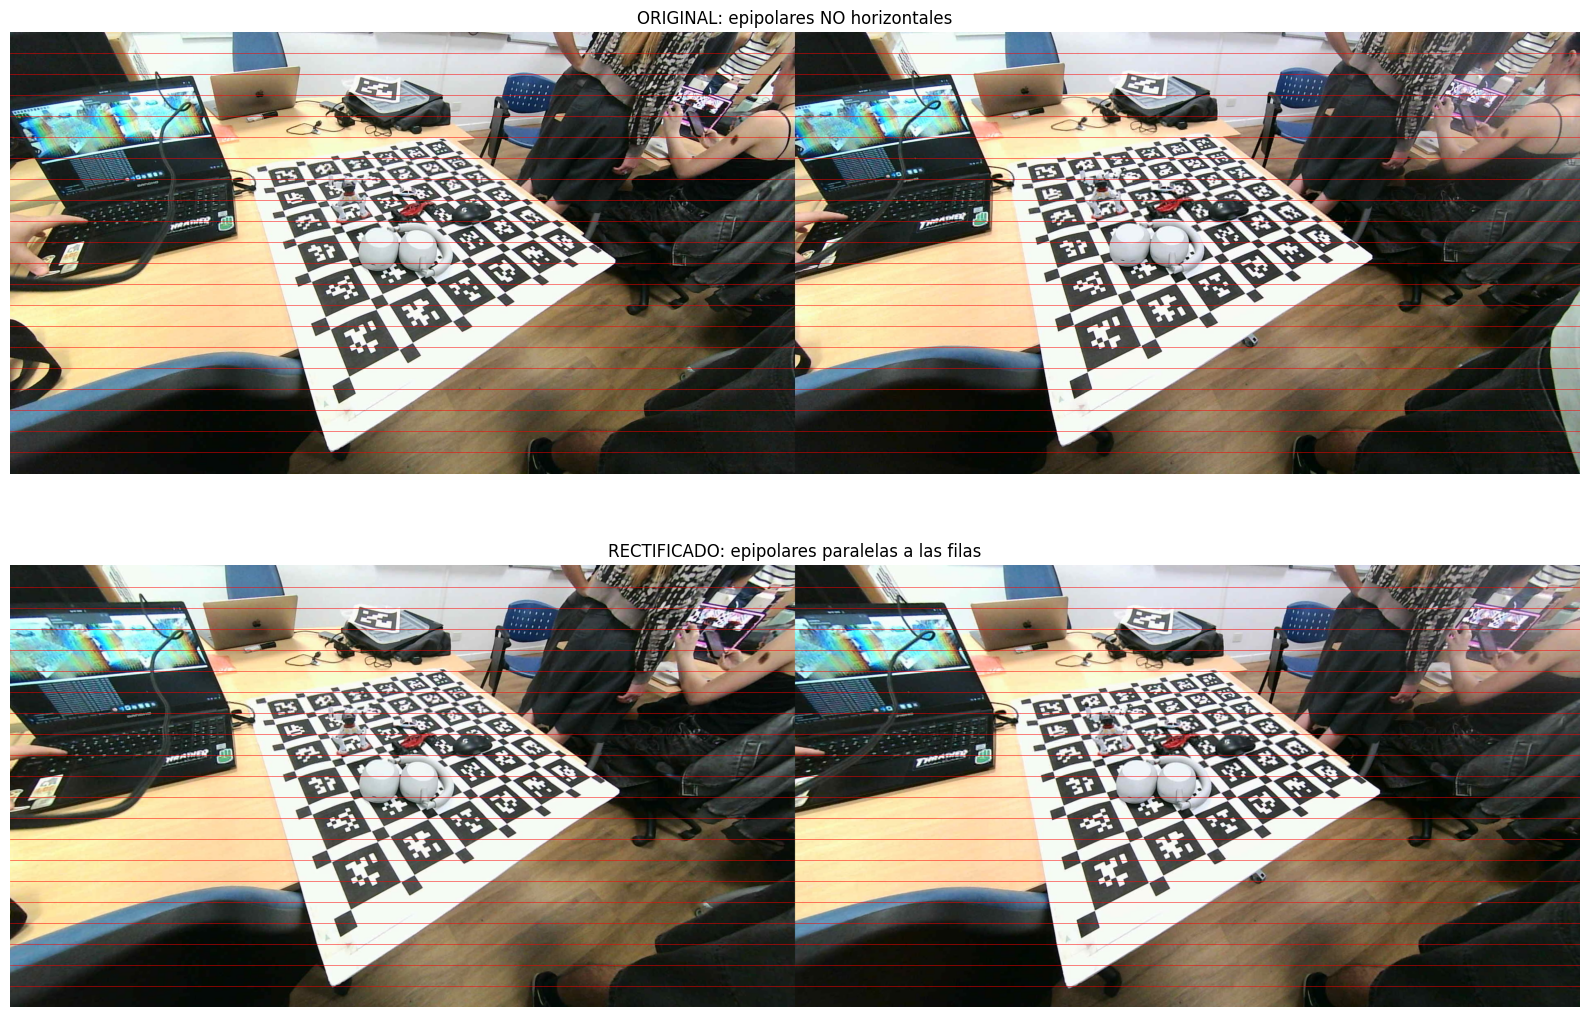

In [10]:
# 2.3 Aplicar a un par de capturas para verificar que las epipolares quedan
# horizontales. Mismo helper que catedra (stereo.ipynb cell 38).
left_raw = cv2.imread(str(CAPTURES_DIR / "left_0.jpg"))
right_raw = cv2.imread(str(CAPTURES_DIR / "right_0.jpg"))
left_rect, right_rect = rectify(left_raw, right_raw)

# Mostrar lado a lado con lineas horizontales para sanity-check de epipolares
fig, axes = plt.subplots(2, 1, figsize=(16, 11))
for ax, (Lp, Rp, t) in zip(axes, [
    (left_raw, right_raw, "ORIGINAL: epipolares NO horizontales"),
    (left_rect, right_rect, "RECTIFICADO: epipolares paralelas a las filas"),
]):
    combined = np.hstack([cv2.cvtColor(Lp, cv2.COLOR_BGR2RGB),
                          cv2.cvtColor(Rp, cv2.COLOR_BGR2RGB)])
    ax.imshow(combined)
    h = combined.shape[0]
    for y in np.linspace(0, h-1, 22)[1:-1]:
        ax.axhline(y=y, color="red", linewidth=0.5, alpha=0.7)
    ax.set_title(t); ax.axis("off")
plt.tight_layout(); plt.show()

## 3. Disparidad

Disparidad = diferencia horizontal entre la posicion de un mismo punto en las imagenes left y right rectificadas. A mas disparidad, mas cerca de la camara: `Z = f * B / d`.

Catedra muestra tres metodos en [stereo.ipynb](ejemplos%20clase/stereo.ipynb):

- **`cv2.StereoBM_create`**: Block Matching clasico. Rapido, ruidoso, sufre con zonas sin textura.
- **`cv2.StereoSGBM_create`**: Semi-Global Block Matching. Mejor cobertura, mas costoso.
- **CREStereo** (deep learning, CVPR 2022): red recurrente con correlacion adaptativa. Disparidad densa con bordes limpios y resistencia a zonas planas. Es el que usa catedra para el output final del pipeline.

Elegimos **CREStereo** via la libreria `disparity` que provee catedra en `ejemplos clase/disparity/`. Corre ONNX -- requiere `onnxruntime`. El modelo se descarga la primera vez a `models/` y queda cacheado.

Salida en pixels (float32); para validez usamos `disparity > 0`.

models\crestereo_combined_iter5_720x1280.onnx


c:\Users\santi\Documents\Dev\tp2_reconstruccion_3d\.venv\Lib\site-packages\onnxruntime\capi\onnxruntime_inference_collection.py:149: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


disparidad   min=5.50, max=198.18, mean=60.35 px
cobertura    100.0% de los pixeles validos
profundidad  ~191 mm a ~6899 mm


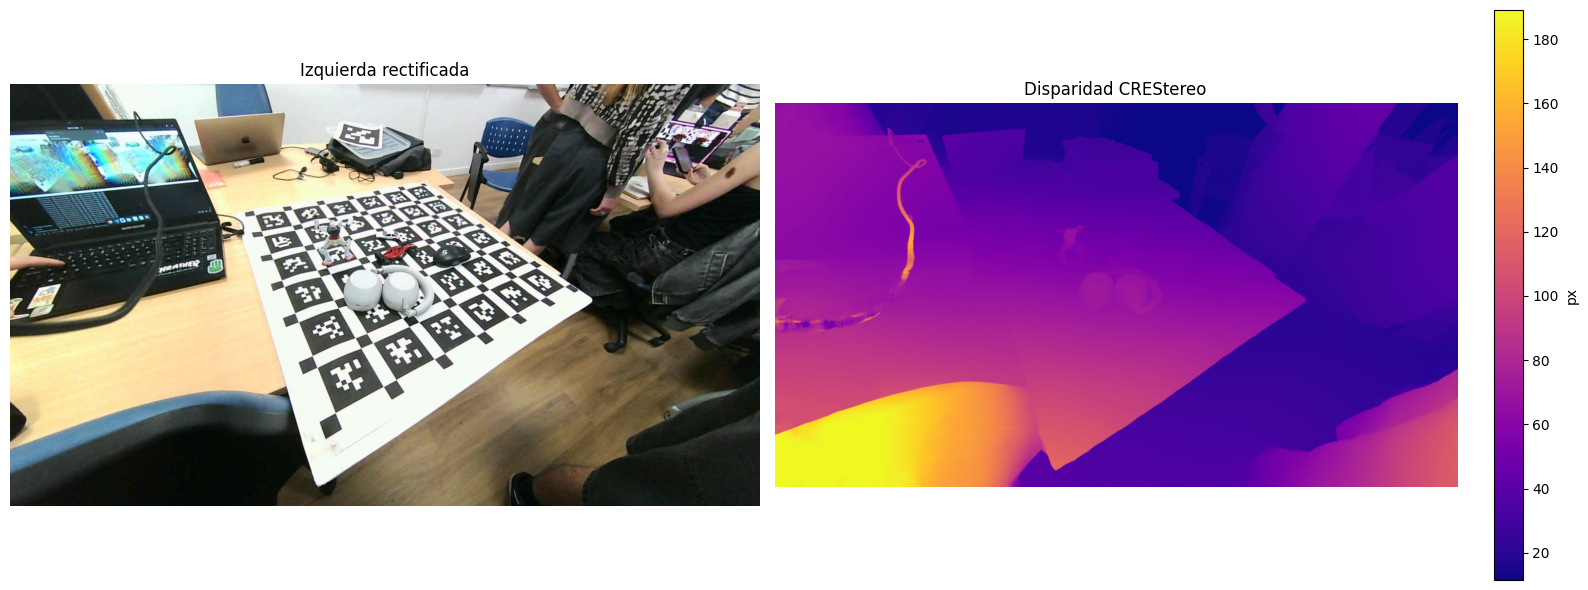

In [11]:
# 3.1 Disparidad con CREStereo (CRE Stereo, CVPR 2022).
# Setup tomado de catedra (stereo.ipynb): Calibration + InputPair + method.compute_disparity.
# La primera ejecucion descarga el modelo .onnx (~30 MB) a models/; despues queda cacheado.
import sys
sys.path.insert(0, "ejemplos clase")
from disparity.method_cre_stereo import CREStereo
from disparity.methods import Calibration, InputPair, Config

w, h = IMAGE_SIZE
fx, fy = float(K_L[0, 0]), float(K_L[1, 1])
cx0, cy0 = float(K_L[0, 2]), float(K_L[1, 2])

calibration = Calibration(**{
    "width": w, "height": h,
    "baseline_meters": baseline_mm / 1000,
    "fx": fx, "fy": fy,
    "cx0": cx0, "cx1": cx0, "cy": cy0,
    "depth_range": [0.05, 20.0],
    "left_image_rect_normalized": [0, 0, 1, 1],
})

models_path = Path("models"); models_path.mkdir(exist_ok=True)
config = Config(models_path=models_path)

method = CREStereo(config)
method.parameters["Shape"].set_value("1280x720")  # 320x240 / 640x480 / 1280x720
# Defaults: Mode="combined" (2 pasadas), Iterations=10. Mas iters = mejor, mas lento.

def compute_disparity(left_rect, right_rect):
    pair = InputPair(left_rect, right_rect, calibration)
    return method.compute_disparity(pair).disparity_pixels


disparity_map = compute_disparity(left_rect, right_rect)
valid = disparity_map > 0
print(f"disparidad   min={disparity_map[valid].min():.2f}, max={disparity_map[valid].max():.2f}, mean={disparity_map[valid].mean():.2f} px")
print(f"cobertura    {valid.mean()*100:.1f}% de los pixeles validos")

f_px = P1[0, 0]
B_mm = -P2[0, 3] / P2[0, 0]
z_min = f_px * B_mm / disparity_map[valid].max()
z_max = f_px * B_mm / disparity_map[valid].min()
print(f"profundidad  ~{z_min:.0f} mm a ~{z_max:.0f} mm")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(cv2.cvtColor(left_rect, cv2.COLOR_BGR2RGB))
axes[0].set_title("Izquierda rectificada"); axes[0].axis("off")
disp_show = np.where(valid, disparity_map, np.nan)
vmin = float(np.nanpercentile(disp_show, 2))
vmax = float(np.nanpercentile(disp_show, 98))
im = axes[1].imshow(disp_show, cmap="plasma", vmin=vmin, vmax=vmax)
axes[1].set_title("Disparidad CREStereo")
axes[1].axis("off")
fig.colorbar(im, ax=axes[1], fraction=0.04, label="px")
plt.tight_layout(); plt.show()

## 4. Pose de la cámara respecto al mundo

Para poder fusionar las nubes parciales de los distintos pares en un único frame necesitamos saber, en cada captura, cómo está orientada la cámara izquierda respecto al mundo. Definimos ese mundo anclando el origen al ChArUco que aparece en escena.

**Diccionario del board** (encontrado por fuerza bruta — el board fue impreso con un dict no estándar): `DICT_ARUCO_MIP_36H12`. Sobre 5 capturas detecta 109 markers (avg ~22/imagen) y los otros 6×6 dicts disponibles (`DICT_6X6_*`, `DICT_APRILTAG_36H1*`) dan 0-2. La celda 4.1 incluye el barrido como sanity-check reproducible.

**Approach de pose**: como no tenemos el mapping `id → celda` que eligió Gastón al armar el board, **no podemos usar `cv2.aruco.CharucoBoard`** (que requiere conocer las posiciones 3D de cada marker). En su lugar anclamos el frame del mundo a UN marker individual:

1. Detectar todos los markers en la imagen izquierda **original** (no la rectificada — `K_L`, `D_L` describen el sensor sin rectificar).
2. Elegir como **anchor** el marker con el ID más chico visible (determinístico y reproducible entre capturas, siempre que ese marker esté en frame).
3. `cv2.solvePnP` con `SOLVEPNP_IPPE_SQUARE` sobre las 4 esquinas del anchor y el tamaño conocido (`CHARUCO_MARKER_MM = 64`). Devuelve `rvec, tvec` que llevan puntos del frame DEL marker al frame de la cámara izquierda.
4. Sanity-check visual: proyectar los ejes X (rojo), Y (verde), Z (azul) con `cv2.drawFrameAxes` y verificar que apuntan donde corresponde (X y Y sobre el plano del board, Z saliendo perpendicular).

> **Limitación**: la pose queda relativa al marker anchor, no al centro del board. Si el anchor está en una esquina del board, el origen del mundo va a quedar ahí — para mediciones absolutas conviene anotarlo, pero para fusión y altura del buda alcanza con que sea consistente entre capturas.

In [12]:
# 4.1 Brute-force del diccionario sobre una muestra de 5 capturas. Reproducible.
# Los dicts 6x6 disponibles son DICT_6X6_{50,100,250,1000} + DICT_ARUCO_MIP_36H12
# + DICT_APRILTAG_36H{10,11}. Esperamos que solo uno detecte algo en estas imagenes.
candidate_dicts = [
    "DICT_6X6_50", "DICT_6X6_100", "DICT_6X6_250", "DICT_6X6_1000",
    "DICT_ARUCO_MIP_36H12",
    "DICT_APRILTAG_36H10", "DICT_APRILTAG_36H11",
]
sample_files = [CAPTURES_DIR / f"left_{i}.jpg" for i in [0, 5, 10, 15, 20]]
sample_imgs = [cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) for p in sample_files]

bf_params = cv2.aruco.DetectorParameters()
bf_params.errorCorrectionRate = 0.7
bf_params.minMarkerPerimeterRate = 0.02

print(f"{'Dict':30s}  total  por-imagen")
print("-" * 60)
bf_results = []
for name in candidate_dicts:
    dic = cv2.aruco.getPredefinedDictionary(getattr(cv2.aruco, name))
    det = cv2.aruco.ArucoDetector(dic, bf_params)
    counts = []
    for img in sample_imgs:
        _, ids, _ = det.detectMarkers(img)
        counts.append(0 if ids is None else len(ids))
    total = sum(counts)
    bf_results.append((name, total, counts))
    print(f"{name:30s}  {total:5d}  {counts}")

winner_name, winner_total, _ = max(bf_results, key=lambda r: r[1])
print(f"\nGanador: {winner_name} ({winner_total} markers totales)")
assert winner_name == "DICT_ARUCO_MIP_36H12", "Cambio el dict ganador, revisar"

Dict                            total  por-imagen
------------------------------------------------------------
DICT_6X6_50                         0  [0, 0, 0, 0, 0]
DICT_6X6_100                        0  [0, 0, 0, 0, 0]
DICT_6X6_250                        0  [0, 0, 0, 0, 0]
DICT_6X6_1000                       0  [0, 0, 0, 0, 0]
DICT_ARUCO_MIP_36H12              109  [26, 26, 20, 11, 26]
DICT_APRILTAG_36H10                 0  [0, 0, 0, 0, 0]
DICT_APRILTAG_36H11                 2  [0, 0, 0, 2, 0]

Ganador: DICT_ARUCO_MIP_36H12 (109 markers totales)


Markers del board (post-filtros): 8
Anchor: ID=8  perimetro=285 px
  (rvec, tvec de ID=8 canonizado face-camera)
tvec (mm en frame de camara izq) = [-184.6, -61.1, 458.7]
distancia camara-anchor: 498.2 mm

Direccion de cada eje del mundo en frame de camara
  X(red)  : [+0.49, +0.67, -0.55]  ~ +Y(down) 
  Y(green): [+0.87, -0.31, +0.39]  ~ +X(right)
  Z(blue) : [+0.09, -0.67, -0.74]  ~ -Z(fwd)  


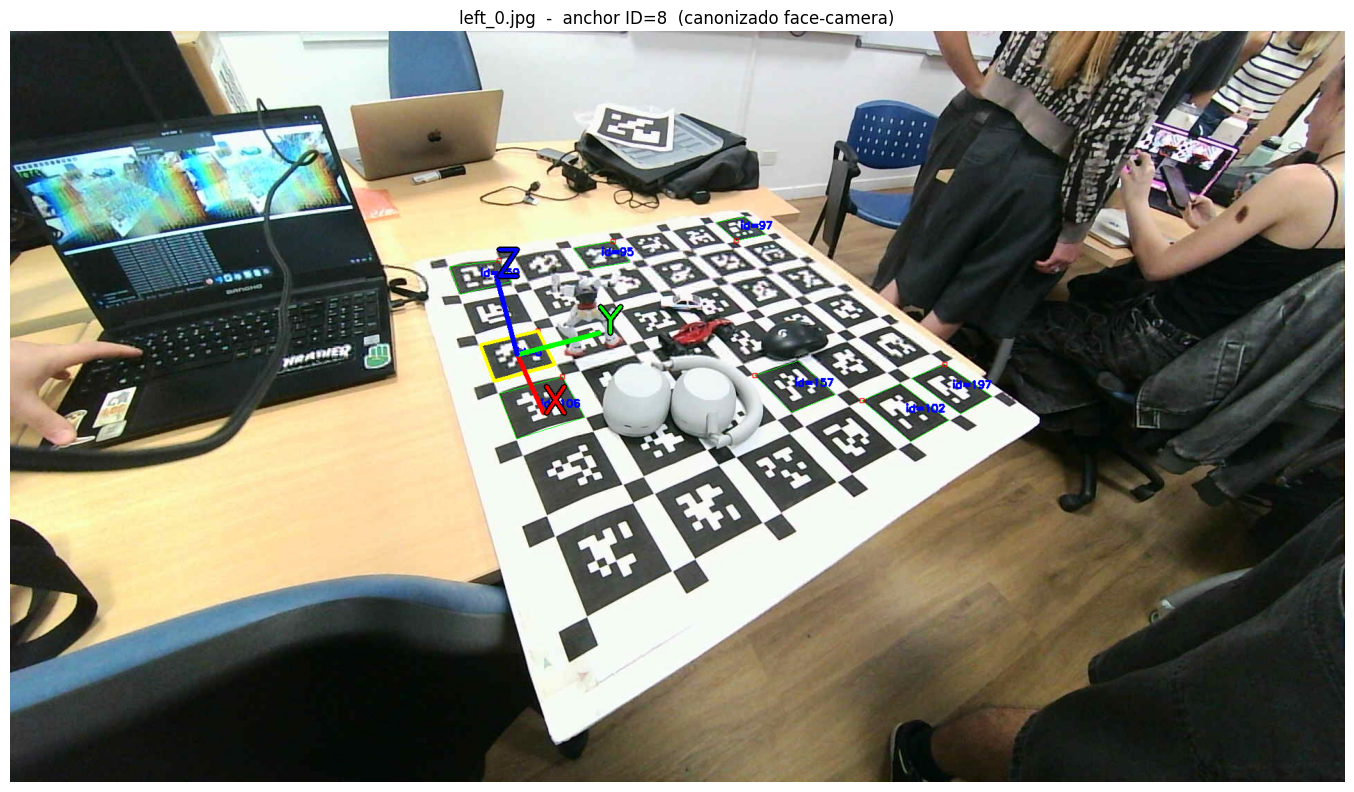

In [13]:
# 4.2 Pose del mundo. Pipeline:
#   1) Detectar markers, deduplicar por ID
#   2) Filtrar perimetros < min_perimeter
#   3) Para CADA marker: solvePnPGeneric con IPPE_SQUARE -> 2 soluciones.
#      Elegir la que tiene +Z marker apuntando HACIA la camara (R[2,2] minimo).
#      Geometricamente unica: el marker esta visible -> esta de frente.
#      Esto resuelve la planar pose ambiguity (sin esto, el solver puede
#      elegir distintas soluciones entre capturas y el frame del mundo "salta").
#   4) Filtro de orientacion: +Z dentro de plane_tol_deg de la mediana
#   5) Anchor inicial = mas grande post-filtro (para world-Z)
#   6) Filtro world-Z: |Z_world| <= z_tol_mm
#   7) Rotacion = R(ID=8) si esta visible, sino R del mas grande del board.
#      No promediamos rotaciones de varios markers porque no podemos asumir
#      que todos tienen la misma orientacion impresa en el board.
#   8) Traslacion = tvec del marker preferido (ID=8) -> origen consistente.

GLOBAL_ANCHOR_ID = 8  # marker mas frecuente entre capturas (37/39)

half = CHARUCO_MARKER_MM / 2
marker_obj_pts = np.array([
    [-half,  half, 0],   # TL
    [ half,  half, 0],   # TR
    [ half, -half, 0],   # BR
    [-half, -half, 0],   # BL
], dtype=np.float32)

aruco_params = cv2.aruco.DetectorParameters()
aruco_params.errorCorrectionRate = 0.7
aruco_params.minMarkerPerimeterRate = 0.02
aruco_detector = cv2.aruco.ArucoDetector(CHARUCO_DICT, aruco_params)


def marker_perimeter(c):
    p = c[0]
    return float(sum(np.linalg.norm(p[(i + 1) % 4] - p[i]) for i in range(4)))


def solve_marker_pose_facing_camera(image_pts, K, dist):
    """solvePnPGeneric con IPPE_SQUARE -> elige la solucion con +Z marker
    apuntando hacia la camara (resuelve planar pose ambiguity).
    Devuelve (rvec, tvec, R) o None."""
    n_sols, rvs, tvs, _ = cv2.solvePnPGeneric(
        marker_obj_pts, image_pts, K, dist, flags=cv2.SOLVEPNP_IPPE_SQUARE,
    )
    if n_sols == 0:
        return None
    best_j, best_z = -1, float("inf")
    for j in range(n_sols):
        Rj, _ = cv2.Rodrigues(rvs[j])
        # +Z marker en camara = Rj[:,2]. Componente Z<0 -> marker de frente.
        if Rj[2, 2] < best_z:
            best_z = Rj[2, 2]
            best_j = j
    R, _ = cv2.Rodrigues(rvs[best_j])
    return rvs[best_j], tvs[best_j], R


def estimate_world_pose(left_image_bgr, K, dist,
                        min_perimeter=120.0,
                        plane_tol_deg=15.0,
                        z_tol_mm=30.0,
                        preferred_anchor_id=GLOBAL_ANCHOR_ID,
                        require_preferred=False):
    """Pose del mundo: anchor preferido (ID=8) con canonizacion face-camera.
    Devuelve (rvec, tvec, anchor_id, board_corners, board_ids) o None."""
    gray = cv2.cvtColor(left_image_bgr, cv2.COLOR_BGR2GRAY) if left_image_bgr.ndim == 3 else left_image_bgr
    corners, ids, _ = aruco_detector.detectMarkers(gray)
    if ids is None or len(ids) == 0:
        return None

    perims = np.array([marker_perimeter(c) for c in corners])

    keep = {}
    for i, mid in enumerate(ids.ravel()):
        mid = int(mid)
        if mid not in keep or perims[keep[mid]] < perims[i]:
            keep[mid] = i
    dedup_idx = np.array(sorted(keep.values()), dtype=int)
    big_idx = dedup_idx[perims[dedup_idx] >= min_perimeter]
    if len(big_idx) == 0:
        return None

    # Pose canonizada (face-camera) de cada marker
    rvecs_per = [None] * len(big_idx)
    tvecs_per = [None] * len(big_idx)
    z_dirs    = [None] * len(big_idx)
    for k, i in enumerate(big_idx):
        ipts = corners[i][0].astype(np.float32)
        sol = solve_marker_pose_facing_camera(ipts, K, dist)
        if sol is None:
            continue
        rvecs_per[k], tvecs_per[k], R = sol
        z_dirs[k] = R[:, 2]

    valid = np.array([z is not None for z in z_dirs])
    if not valid.any():
        return None

    # Filtro de orientacion
    z_arr = np.stack([z for z in z_dirs if z is not None])
    z_median = np.median(z_arr, axis=0); z_median /= np.linalg.norm(z_median)
    cos_tol = np.cos(np.radians(plane_tol_deg))
    plane_ok = np.array([(z is not None) and (np.dot(z, z_median) >= cos_tol) for z in z_dirs])
    if not plane_ok.any():
        return None

    # Anchor inicial (para filtro world-Z)
    plane_perims = np.where(plane_ok, perims[big_idx], -1.0)
    init_local = int(np.argmax(plane_perims))
    R_init, _ = cv2.Rodrigues(rvecs_per[init_local])
    t_init = tvecs_per[init_local].ravel()

    # Filtro world-Z
    z_world_ok = np.zeros(len(big_idx), dtype=bool)
    for k in range(len(big_idx)):
        if not plane_ok[k] or tvecs_per[k] is None:
            continue
        pw = R_init.T @ (tvecs_per[k].ravel() - t_init)
        if abs(pw[2]) <= z_tol_mm:
            z_world_ok[k] = True

    on_board = plane_ok & z_world_ok
    if not on_board.any():
        return None

    board_idx_local = np.where(on_board)[0]
    board_corners = tuple(corners[big_idx[i]] for i in board_idx_local)
    board_ids = ids[big_idx[board_idx_local]]
    board_perims = perims[big_idx[board_idx_local]]
    board_ids_flat = board_ids.ravel()

    # Anchor final: ID=8 si esta, sino el mas grande del board
    if preferred_anchor_id is not None and preferred_anchor_id in board_ids_flat:
        anchor_local = int(np.where(board_ids_flat == preferred_anchor_id)[0][0])
    elif require_preferred:
        return None
    else:
        anchor_local = int(np.argmax(board_perims))
    anchor_id = int(board_ids_flat[anchor_local])
    rvec = rvecs_per[board_idx_local[anchor_local]]
    tvec = tvecs_per[board_idx_local[anchor_local]]
    return rvec, tvec, anchor_id, board_corners, board_ids


# Test en left_0.jpg (imagen ORIGINAL, no rectificada)
test_img = cv2.imread(str(CAPTURES_DIR / "left_0.jpg"))
result = estimate_world_pose(test_img, K_L, D_L)
assert result is not None, "No se detecto ningun marker en left_0.jpg"
rvec, tvec, anchor_id, board_corners, board_ids = result
anchor_idx = int(np.where(board_ids.ravel() == anchor_id)[0][0])

print(f"Markers del board (post-filtros): {len(board_ids)}")
print(f"Anchor: ID={anchor_id}  perimetro={marker_perimeter(board_corners[anchor_idx]):.0f} px")
print(f"  (rvec, tvec de ID={anchor_id} canonizado face-camera)")
print(f"tvec (mm en frame de camara izq) = [{tvec[0,0]:.1f}, {tvec[1,0]:.1f}, {tvec[2,0]:.1f}]")
print(f"distancia camara-anchor: {np.linalg.norm(tvec):.1f} mm")

R_dbg, _ = cv2.Rodrigues(rvec)
print("\nDireccion de cada eje del mundo en frame de camara")
for name, vec in [("X(red)  ", R_dbg[:, 0]), ("Y(green)", R_dbg[:, 1]), ("Z(blue) ", R_dbg[:, 2])]:
    i = int(np.argmax(np.abs(vec)))
    sign = "+" if vec[i] > 0 else "-"
    axis = ["X(right)", "Y(down) ", "Z(fwd)  "][i]
    print(f"  {name}: [{vec[0]:+.2f}, {vec[1]:+.2f}, {vec[2]:+.2f}]  ~ {sign}{axis}")

vis = test_img.copy()
cv2.aruco.drawDetectedMarkers(vis, board_corners, board_ids)
anchor_pts = board_corners[anchor_idx][0].astype(int)
cv2.polylines(vis, [anchor_pts], True, (0, 255, 255), 4)

axis_len_mm = CHARUCO_MARKER_MM * 1.5
cv2.drawFrameAxes(vis, K_L, D_L, rvec, tvec, length=axis_len_mm, thickness=5)

labels_3d = np.float32([[axis_len_mm, 0, 0], [0, axis_len_mm, 0], [0, 0, axis_len_mm]])
labels_2d, _ = cv2.projectPoints(labels_3d, rvec, tvec, K_L, D_L)
for (label, color), pt in zip([("X", (0, 0, 255)), ("Y", (0, 255, 0)), ("Z", (255, 0, 0))],
                               labels_2d.reshape(-1, 2)):
    cv2.putText(vis, label, tuple(pt.astype(int)), cv2.FONT_HERSHEY_SIMPLEX, 1.8, (0, 0, 0), 8)
    cv2.putText(vis, label, tuple(pt.astype(int)), cv2.FONT_HERSHEY_SIMPLEX, 1.8, color, 3)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
ax.set_title(f"left_0.jpg  -  anchor ID={anchor_id}  (canonizado face-camera)")
ax.axis("off")
plt.tight_layout(); plt.show()

## 5. Reconstrucción 3D de un par

Siguiendo el ejemplo de cátedra ([stereo.ipynb](ejemplos%20clase/stereo.ipynb) — `compute_depth` + back-projection):

1. **Depth**: `Z = f * B / d` para cada pixel con disparidad válida (`compute_depth` helper, igual al de cátedra).
2. **Back-projection**: para cada pixel `(u, v)` con depth `Z`, el punto 3D en el frame de cámara izq RECTIFICADA es `X = (u - cx) * Z / f`, `Y = (v - cy) * Z / f`. Usamos `f, cx, cy` de la matriz rectificada `P1` (no `K_L`) — la disparidad vive en el frame rectificado.
3. **Filtro**: descartamos disparidad `≤ 0` (inválidos) y profundidades fuera de `[100, 2000] mm` (el buda está a ~30-100 cm de la cámara; eso descarta fondo y artefactos).
4. **Llevar al mundo**: tenemos puntos en frame **rectificado**, pero la pose del marker (sección 4.2) está en frame **sin rectificar**. La cadena correcta es:
   ```
   P_world = R_marker^T · (R1^T · P_rect − t_marker)
   ```
   Componemos las dos transformaciones en una matriz 4×4 `T_world_rect` y aplicamos al batch entero.
5. **PointCloud**: `o3d.geometry.PointCloud` con los puntos transformados y los colores del pixel correspondiente en la izquierda rectificada.

Comparado con `cv2.reprojectImageTo3D(disparity, Q)` (que también funcionaría y es lo que algunos tutoriales muestran), `compute_depth` + back-projection manual es lo que hace cátedra y queda más explícito qué pasa con cada componente.

Anchor ID: 8  -  Total puntos: 1,901,833
Markers del board: 8
Slab Z[-50, 300] (sin recorte X/Y): 410,092 puntos
BBOX board X[-264,337] Y[-82,512]: 1,160 puntos


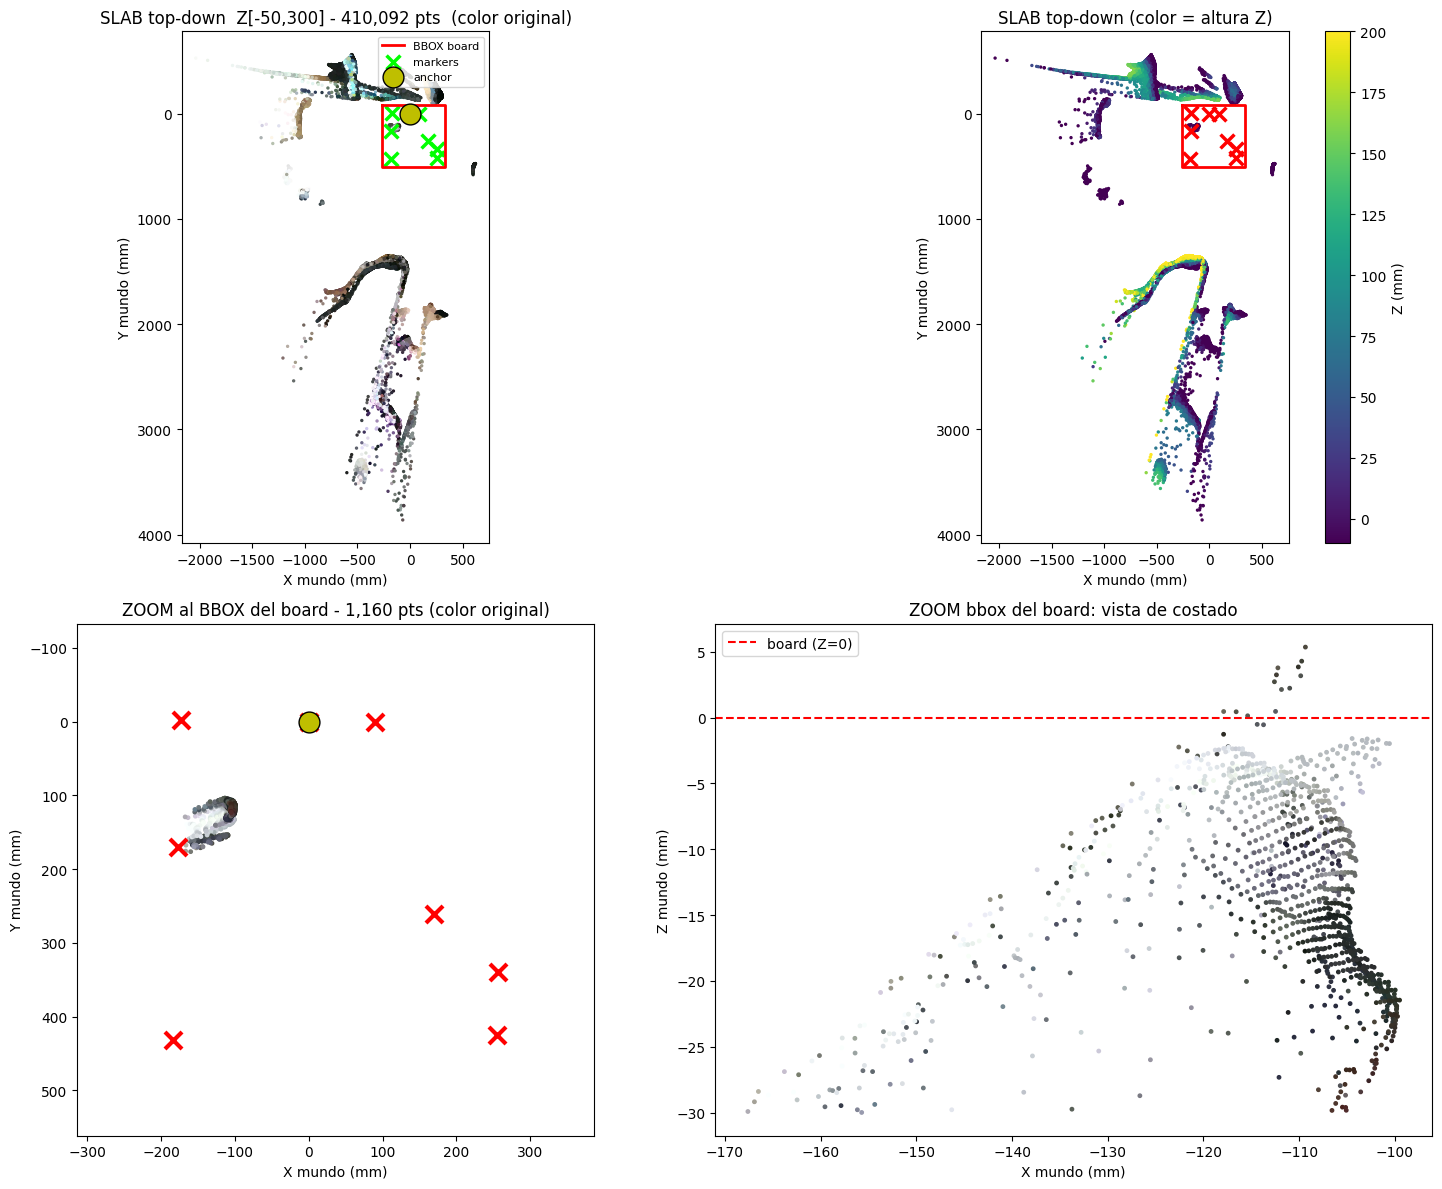

In [14]:
# 5.1 Reconstruccion 3D de left_0 (par de prueba). Sigue catedra (compute_depth +
# back-projection (u-cx)*Z/f), filtra, transforma al frame del mundo y arma una
# o3d.PointCloud lista para fusionar en seccion 6.

def compute_depth(disparity_map, f, B):
    """Z = f * B / disparidad. Disparidad <= 0 -> 0 (se filtra despues)."""
    depth = np.zeros_like(disparity_map, dtype=np.float32)
    valid = disparity_map > 0
    depth[valid] = (f * B) / disparity_map[valid]
    return depth, valid


def pair_to_world_pointcloud(
    left_raw_bgr, left_rect_bgr, disparity_map,
    K_unrect, dist_unrect, P1, R1, P2,
    depth_min_mm=100.0, depth_max_mm=2000.0,
):
    """Reconstruccion 3D de un par stereo en el frame del mundo (marker anchor).
    Devuelve (pcd, anchor_id, board_markers_world) o (None, None, None) si fallo."""
    pose = estimate_world_pose(left_raw_bgr, K_unrect, dist_unrect)
    if pose is None:
        return None, None, None
    rvec, tvec, anchor_id, big_corners, big_ids = pose
    R_marker, _ = cv2.Rodrigues(rvec)

    markers_world = []
    for c in big_corners:
        ipts = c[0].astype(np.float32)
        ok, rv, tv = cv2.solvePnP(marker_obj_pts, ipts, K_unrect, dist_unrect,
                                   flags=cv2.SOLVEPNP_IPPE_SQUARE)
        if ok:
            pos_world = (R_marker.T @ (tv - tvec)).ravel()
            markers_world.append(pos_world)
    markers_world = np.array(markers_world) if markers_world else np.zeros((0, 3))

    f_px = float(P1[0, 0])
    B_mm = float(-P2[0, 3] / P2[0, 0])
    cx = float(P1[0, 2]); cy = float(P1[1, 2])
    depth, valid_disp = compute_depth(disparity_map, f_px, B_mm)

    H, W = depth.shape
    v_grid, u_grid = np.mgrid[0:H, 0:W].astype(np.float32)
    X = (u_grid - cx) * depth / f_px
    Y = (v_grid - cy) * depth / f_px
    Z = depth
    points_rect = np.stack([X, Y, Z], axis=-1)

    mask = valid_disp & (Z >= depth_min_mm) & (Z <= depth_max_mm)
    pts_rect = points_rect[mask].astype(np.float32)
    colors = cv2.cvtColor(left_rect_bgr, cv2.COLOR_BGR2RGB)[mask] / 255.0

    T_unrect_rect = np.eye(4); T_unrect_rect[:3, :3] = R1.T
    T_world_unrect = np.eye(4)
    T_world_unrect[:3, :3] = R_marker.T
    T_world_unrect[:3, 3] = (-R_marker.T @ tvec).ravel()
    T_world_rect = T_world_unrect @ T_unrect_rect

    pts_h = np.hstack([pts_rect, np.ones((len(pts_rect), 1), dtype=np.float32)])
    pts_world = (pts_h @ T_world_rect.T)[:, :3]

    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts_world)
    pcd.colors = o3d.utility.Vector3dVector(colors)
    return pcd, anchor_id, markers_world


# --- Aplicacion al par 0 ---
left_raw_0 = cv2.imread(str(CAPTURES_DIR / "left_0.jpg"))
pcd, anchor_id, mw = pair_to_world_pointcloud(
    left_raw_0, left_rect, disparity_map, K_L, D_L, P1, R1, P2,
)
assert pcd is not None, "estimate_world_pose fallo en left_0"

pts_all = np.asarray(pcd.points)
col_all = np.asarray(pcd.colors)
print(f"Anchor ID: {anchor_id}  -  Total puntos: {len(pts_all):,}")
print(f"Markers del board: {len(mw)}")

# Slab horizontal AMPLIO (sin bbox X/Y) -- todo lo que esta cerca del plano
# del board (incluye mesa, board, objetos encima). Util para ver donde cae
# realmente el cloud reconstruido.
SLAB_Z_MIN, SLAB_Z_MAX = -50.0, 300.0
slab_mask = (pts_all[:, 2] >= SLAB_Z_MIN) & (pts_all[:, 2] <= SLAB_Z_MAX)
pts_slab = pts_all[slab_mask]
col_slab = col_all[slab_mask]
print(f"Slab Z[{SLAB_Z_MIN:.0f}, {SLAB_Z_MAX:.0f}] (sin recorte X/Y): {len(pts_slab):,} puntos")

# BBOX estrecho del board (bbox de markers + margen)
on_board = np.abs(mw[:, 2]) < 30
mw_board = mw[on_board]
MARGIN = 80
xmin = float(mw_board[:, 0].min()) - MARGIN
xmax = float(mw_board[:, 0].max()) + MARGIN
ymin = float(mw_board[:, 1].min()) - MARGIN
ymax = float(mw_board[:, 1].max()) + MARGIN
BOARD_BBOX = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=np.array([xmin, ymin,  -30.0]),
    max_bound=np.array([xmax, ymax,  300.0]),
)
pcd_board = pcd.crop(BOARD_BBOX)
pts_b = np.asarray(pcd_board.points)
col_b = np.asarray(pcd_board.colors)
print(f"BBOX board X[{xmin:.0f},{xmax:.0f}] Y[{ymin:.0f},{ymax:.0f}]: {len(pts_b):,} puntos")

def sub(p, c, n=40000):
    if len(p) <= n: return p, c
    i = np.random.default_rng(0).choice(len(p), n, replace=False)
    return p[i], c[i]

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# (0,0) SLAB top-down con COLOR ORIGINAL - vista panoramica de la mesa al nivel del board
ps, cs = sub(pts_slab, col_slab)
axes[0, 0].scatter(ps[:, 0], ps[:, 1], c=cs, s=2)
axes[0, 0].set_aspect("equal"); axes[0, 0].invert_yaxis()
axes[0, 0].set_xlabel("X mundo (mm)"); axes[0, 0].set_ylabel("Y mundo (mm)")
axes[0, 0].set_title(f"SLAB top-down  Z[{SLAB_Z_MIN:.0f},{SLAB_Z_MAX:.0f}] - {len(pts_slab):,} pts  (color original)")
axes[0, 0].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin],
                "r-", lw=2, label="BBOX board")
axes[0, 0].scatter(mw_board[:, 0], mw_board[:, 1], marker="x", c="lime", s=100, linewidth=2.5, label="markers")
axes[0, 0].plot(0, 0, "yo", markersize=15, markeredgecolor="black", label="anchor")
axes[0, 0].legend(loc="upper right", fontsize=8)

# (0,1) SLAB top-down con COLOR = ALTURA - revela objetos altos en toda la escena
sc = axes[0, 1].scatter(ps[:, 0], ps[:, 1], c=ps[:, 2], s=2, cmap="viridis", vmin=-10, vmax=200)
axes[0, 1].set_aspect("equal"); axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel("X mundo (mm)"); axes[0, 1].set_ylabel("Y mundo (mm)")
axes[0, 1].set_title("SLAB top-down (color = altura Z)")
plt.colorbar(sc, ax=axes[0, 1], label="Z (mm)")
axes[0, 1].plot([xmin, xmax, xmax, xmin, xmin], [ymin, ymin, ymax, ymax, ymin], "r-", lw=2)
axes[0, 1].scatter(mw_board[:, 0], mw_board[:, 1], marker="x", c="red", s=100, linewidth=2.5)

# (1,0) BBOX board zoom: solo lo que cae adentro del bbox
if len(pts_b) > 0:
    pb, cb = sub(pts_b, col_b)
    axes[1, 0].scatter(pb[:, 0], pb[:, 1], c=cb, s=6)
    axes[1, 0].set_aspect("equal"); axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlim(xmin - 50, xmax + 50); axes[1, 0].set_ylim(ymax + 50, ymin - 50)
    axes[1, 0].set_xlabel("X mundo (mm)"); axes[1, 0].set_ylabel("Y mundo (mm)")
    axes[1, 0].set_title(f"ZOOM al BBOX del board - {len(pts_b):,} pts (color original)")
    axes[1, 0].scatter(mw_board[:, 0], mw_board[:, 1], marker="x", c="red", s=150, linewidth=3)
    axes[1, 0].plot(0, 0, "yo", markersize=15, markeredgecolor="black")

# (1,1) BBOX board side view
if len(pts_b) > 0:
    pb, cb = sub(pts_b, col_b)
    axes[1, 1].scatter(pb[:, 0], pb[:, 2], c=cb, s=6)
    axes[1, 1].set_xlabel("X mundo (mm)"); axes[1, 1].set_ylabel("Z mundo (mm)")
    axes[1, 1].set_title("ZOOM bbox del board: vista de costado")
    axes[1, 1].axhline(0, color="red", ls="--", lw=1.5, label="board (Z=0)")
    axes[1, 1].legend()

plt.tight_layout(); plt.show()

## 6. Loop sobre todos los pares + acumulación

Iteramos sobre los pares `(left_i, right_i)` de `captures/`, repitiendo para cada par: rectificar → disparidad → pose del mundo → reconstrucción 3D → recorte → acumular.

**Anchor global**: usamos siempre `ID=8` (visible en 37/39 capturas, 94.9%). Los pares donde no aparece se saltean — las 2 capturas perdidas son aceptables para mantener consistencia del frame del mundo entre todas las nubes parciales. Sin esto, cada captura usaría un anchor diferente y las nubes no encajarían entre sí.

**Filtros sobre cada nube parcial** (siguiendo el plan original):
1. `AxisAlignedBoundingBox` en coordenadas de mundo (X, Y ∈ ±500 mm, Z ∈ [-10, +300] mm). Descarta el piso, la silla, la mesa alrededor y todo lo que no esté en el board + objetos arriba.
2. Acumular sumando con `+=`.

**Post-proceso al final del loop**:
1. `remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)` — saca puntos espurios del matching.
2. `voxel_down_sample(voxel_size=1mm)` — mantiene densidad manejable (las 39 nubes parciales se solapan masivamente sobre el buda, sin downsample se hace pesado).

Llevamos cuenta de los pares saltados (sin ID=8 visible o con disparidad fallida) y los reportamos.

Pares de captura: 39


Fusionando capturas:   0%|          | 0/39 [00:00<?, ?it/s]

models\crestereo_combined_iter5_720x1280.onnx


Fusionando capturas:   3%|▎         | 1/39 [00:15<09:51, 15.58s/it]

models\crestereo_combined_iter5_720x1280.onnx


...

models\crestereo_combined_iter5_720x1280.onnx


Fusionando capturas:  97%|█████████▋| 38/39 [07:13<00:10, 10.96s/it]

models\crestereo_combined_iter5_720x1280.onnx


Fusionando capturas: 100%|██████████| 39/39 [07:24<00:00, 11.40s/it]



Procesados OK: 29/39
Saltados: 10
  left_2: no ID=8 visible
  left_3: no ID=8 visible
  left_4: no ID=8 visible
  left_10: no ID=8 visible
  left_11: no ID=8 visible
  left_12: no ID=8 visible
  left_15: no ID=8 visible
  left_28: no ID=8 visible
  left_35: no ID=8 visible
  left_36: no ID=8 visible
Total puntos antes de cleanup: 2,628,898

remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)...
  -> 2,564,693 puntos
voxel_down_sample(voxel_size=1mm)...
  -> 1,040,496 puntos finales


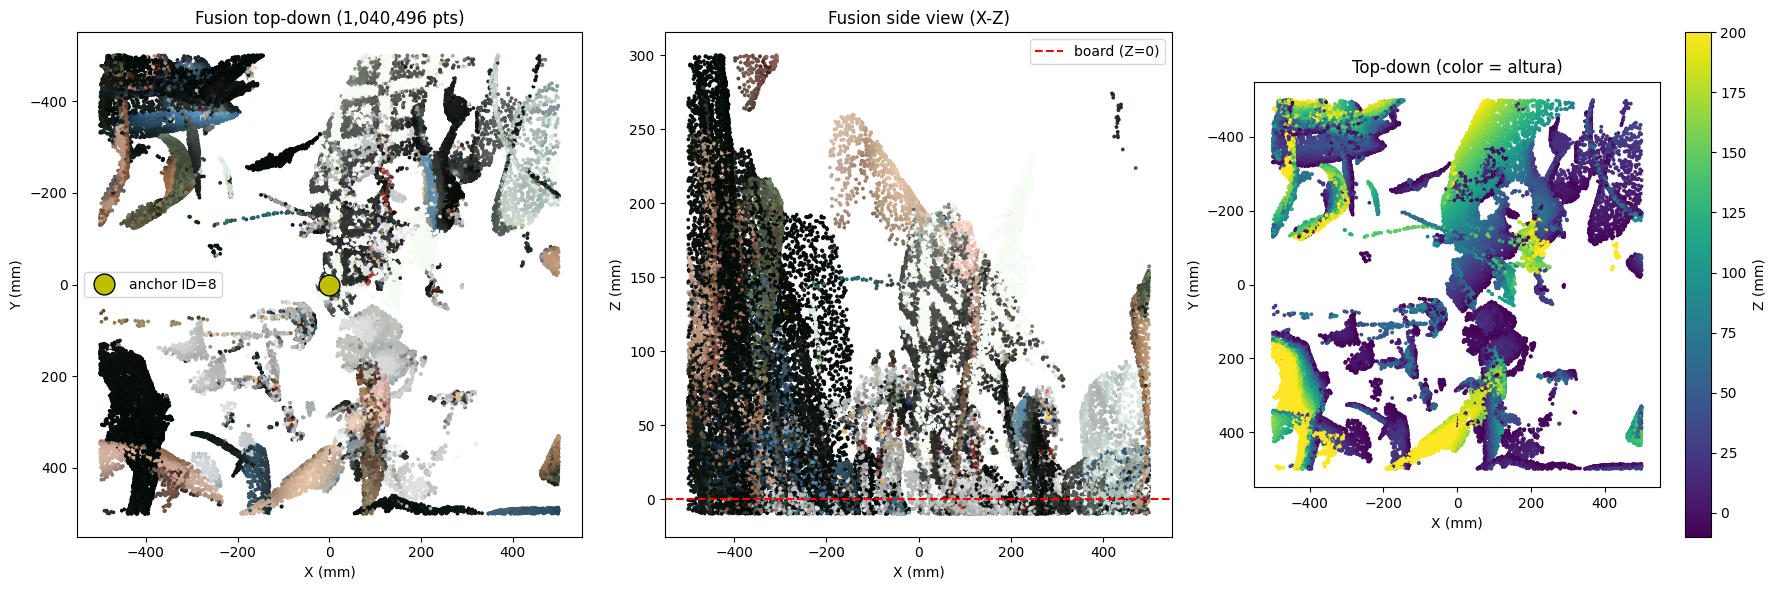

In [15]:
# 6.1 Loop sobre todos los pares -> fusion en world frame con anchor global ID=8

# Listar pares de captura
left_capture_files = sorted(glob.glob(str(CAPTURES_DIR / "left_*.jpg")), key=numeric_sort)
right_capture_files = sorted(glob.glob(str(CAPTURES_DIR / "right_*.jpg")), key=numeric_sort)
assert len(left_capture_files) == len(right_capture_files), "L/R mismatch"
n_pairs = len(left_capture_files)
print(f"Pares de captura: {n_pairs}")

# Bbox del board en el world frame con anchor=ID=8 (generoso para acomodar drift de pose)
buda_bbox = o3d.geometry.AxisAlignedBoundingBox(
    min_bound=np.array([-500.0, -500.0,  -10.0]),
    max_bound=np.array([ 500.0,  500.0,  300.0]),
)

acc = o3d.geometry.PointCloud()
n_ok = 0
skipped = []  # (idx, reason)

for left_f, right_f in tqdm(list(zip(left_capture_files, right_capture_files)),
                              desc="Fusionando capturas"):
    idx = numeric_sort(left_f)
    left_bgr = cv2.imread(left_f)
    right_bgr = cv2.imread(right_f)
    if left_bgr is None or right_bgr is None:
        skipped.append((idx, "imread None")); continue

    # Rectificar
    lrect, rrect = rectify(left_bgr, right_bgr)

    # Disparidad (CREStereo, ~5-15s por par)
    try:
        disp = compute_disparity(lrect, rrect)
    except Exception as e:
        skipped.append((idx, f"disp fail: {e}")); continue

    # Pose: REQUERIR anchor=ID=8 (require_preferred=True) -> consistencia entre capturas
    pose = estimate_world_pose(left_bgr, K_L, D_L, require_preferred=True)
    if pose is None:
        skipped.append((idx, "no ID=8 visible")); continue

    # Reconstruir y transformar al mundo
    pcd_pair, anchor_id_i, _ = pair_to_world_pointcloud(
        left_bgr, lrect, disp, K_L, D_L, P1, R1, P2,
    )
    if pcd_pair is None:
        skipped.append((idx, "recon fail")); continue
    # Sanity check: el anchor de esta captura tiene que ser ID=8 (lo forzamos arriba)
    assert anchor_id_i == GLOBAL_ANCHOR_ID, f"anchor inconsistente: {anchor_id_i} != {GLOBAL_ANCHOR_ID}"

    # Crop a la region del buda en world frame
    pcd_pair = pcd_pair.crop(buda_bbox)
    acc += pcd_pair
    n_ok += 1

print(f"\nProcesados OK: {n_ok}/{n_pairs}")
print(f"Saltados: {len(skipped)}")
for idx, reason in skipped:
    print(f"  left_{idx}: {reason}")
print(f"Total puntos antes de cleanup: {len(acc.points):,}")

# Post-process: outlier removal + voxel downsample
print("\nremove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)...")
acc_clean, _ = acc.remove_statistical_outlier(nb_neighbors=20, std_ratio=2.0)
print(f"  -> {len(acc_clean.points):,} puntos")

print("voxel_down_sample(voxel_size=1mm)...")
acc_final = acc_clean.voxel_down_sample(voxel_size=1.0)
print(f"  -> {len(acc_final.points):,} puntos finales")

# Plots
pts_f = np.asarray(acc_final.points)
col_f = np.asarray(acc_final.colors)

def sub(p, c, n=50000):
    if len(p) <= n: return p, c
    i = np.random.default_rng(0).choice(len(p), n, replace=False)
    return p[i], c[i]

pf, cf = sub(pts_f, col_f)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(pf[:, 0], pf[:, 1], c=cf, s=3)
axes[0].set_aspect("equal"); axes[0].invert_yaxis()
axes[0].set_xlabel("X (mm)"); axes[0].set_ylabel("Y (mm)")
axes[0].set_title(f"Fusion top-down ({len(pts_f):,} pts)")
axes[0].plot(0, 0, "yo", markersize=15, markeredgecolor="black", label=f"anchor ID={GLOBAL_ANCHOR_ID}")
axes[0].legend()

axes[1].scatter(pf[:, 0], pf[:, 2], c=cf, s=3)
axes[1].set_xlabel("X (mm)"); axes[1].set_ylabel("Z (mm)")
axes[1].set_title("Fusion side view (X-Z)")
axes[1].axhline(0, color="red", ls="--", lw=1.5, label="board (Z=0)")
axes[1].legend()

sc = axes[2].scatter(pf[:, 0], pf[:, 1], c=pf[:, 2], s=3, cmap="viridis", vmin=-10, vmax=200)
axes[2].set_aspect("equal"); axes[2].invert_yaxis()
axes[2].set_xlabel("X (mm)"); axes[2].set_ylabel("Y (mm)")
axes[2].set_title("Top-down (color = altura)")
plt.colorbar(sc, ax=axes[2], label="Z (mm)")

plt.tight_layout(); plt.show()